In [1]:
!pip install torch torchvision
!pip install git+https://github.com/openai/CLIP.git
!pip install faiss-gpu
!pip install opencv-python-headless
!pip install gradio
!apt-get install -y ffmpeg

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-47uh0zzj
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-47uh0zzj
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=1b74c7b1707bb4f116f6cc678b35e78d0811a254df3ce599d376ac18e1717397
  Stored in directory: /tmp/pip-ephem-wheel-cache-4ymizgm1/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
ERROR: Could not find a version that satisfies the requirement faiss-gpu (from versions: none)
ERROR: No matching distribution found for faiss-gpu
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubu

In [2]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 41.2 MB/s eta 0:00:00


In [3]:
import os

!wget -O sample_video.mp4 "https://download.blender.org/peach/bigbuckbunny_movies/BigBuckBunny_320x180.mp4"

print("File size:", os.path.getsize("sample_video.mp4"), "bytes")

--2026-04-05 16:42:30--  https://download.blender.org/peach/bigbuckbunny_movies/BigBuckBunny_320x180.mp4
Resolving download.blender.org (download.blender.org)... 172.66.172.236, 104.20.41.146, 2606:4700:10::ac42:acec, ...
Connecting to download.blender.org (download.blender.org)|172.66.172.236|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64657027 (62M) [video/mp4]
Saving to: ‘sample_video.mp4’

sample_video.mp4    100%[===================>]  61.66M   201MB/s    in 0.3s    

2026-04-05 16:42:30 (201 MB/s) - ‘sample_video.mp4’ saved [64657027/64657027]

File size: 64657027 bytes


In [4]:
import cv2
import os

# Create folder to store frames
os.makedirs("frames", exist_ok=True)

# Extract 1 frame per second
cap = cv2.VideoCapture("sample_video.mp4")
video_fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / video_fps

print(f"Video FPS: {video_fps}")
print(f"Total frames: {total_frames}")
print(f"Duration: {duration:.1f} seconds")

frame_idx = 0
saved = 0
timestamps = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    if frame_idx % int(video_fps) == 0:
        timestamp = frame_idx / video_fps
        path = f"frames/frame_{saved:04d}_{timestamp:.1f}s.jpg"
        cv2.imwrite(path, frame)
        timestamps.append(timestamp)
        saved += 1
    frame_idx += 1

cap.release()
print(f"\nExtracted {saved} frames into /frames folder")

Video FPS: 24.0
Total frames: 14315
Duration: 596.5 seconds

Extracted 597 frames into /frames folder


In [5]:
import clip
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm

# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
print(f"CLIP loaded on: {device}")

# Get all frame paths sorted
frame_paths = sorted([f"frames/{f}" for f in os.listdir("frames") if f.endswith(".jpg")])
print(f"Total frames to embed: {len(frame_paths)}")

# Generate embeddings for every frame
embeddings = []
for path in tqdm(frame_paths):
    image = preprocess(Image.open(path)).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model.encode_image(image).cpu().numpy()
    embeddings.append(emb)

embeddings = np.vstack(embeddings).astype("float32")
print(f"\nEmbeddings shape: {embeddings.shape}")

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 87.3MiB/s]


CLIP loaded on: cuda
Total frames to embed: 597


100%|██████████| 597/597 [00:10<00:00, 58.65it/s]


Embeddings shape: (597, 512)


In [6]:
import faiss

# Normalize embeddings (required for cosine similarity)
faiss.normalize_L2(embeddings)

# Build the index
index = faiss.IndexFlatIP(512)  # IP = Inner Product = cosine similarity
index.add(embeddings)

print(f"FAISS index built successfully!")
print(f"Total vectors in index: {index.ntotal}")

FAISS index built successfully!
Total vectors in index: 597


/tmp/ipykernel_572/2619902312.py:28: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


Search results for: 'rabbit running in a field'



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


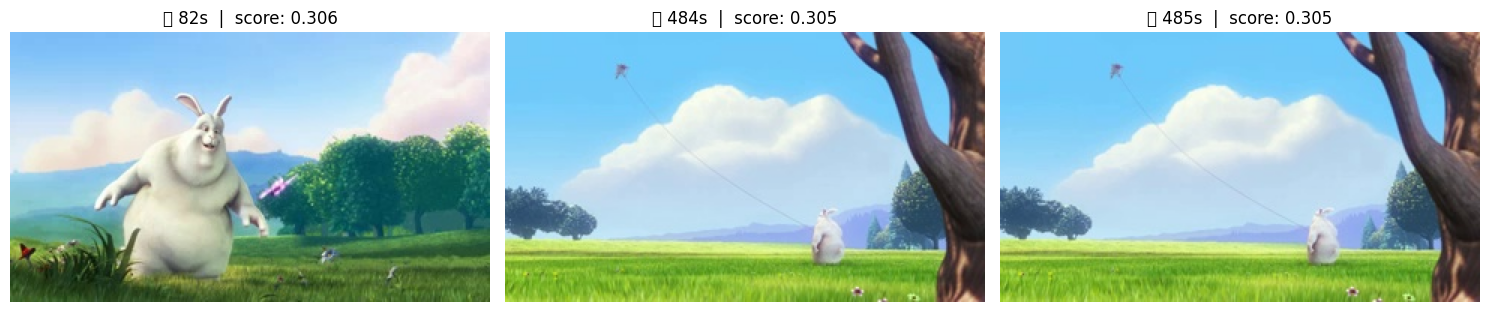

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def search_video(query, top_k=3):
    # Convert text query to CLIP embedding
    text = clip.tokenize([query]).to(device)
    with torch.no_grad():
        text_emb = model.encode_text(text).cpu().numpy().astype("float32")

    faiss.normalize_L2(text_emb)

    # Search FAISS index
    scores, indices = index.search(text_emb, top_k)

    print(f"Search results for: '{query}'\n")

    # Show matching frames
    fig, axes = plt.subplots(1, top_k, figsize=(15, 4))
    for i, idx in enumerate(indices[0]):
        timestamp = timestamps[idx]
        score = scores[0][i]
        img = mpimg.imread(frame_paths[idx])
        axes[i].imshow(img)
        axes[i].set_title(f"⏱ {timestamp:.0f}s  |  score: {score:.3f}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Try it!
search_video("rabbit running in a field")

Search results for: 'butterfly flying'



/tmp/ipykernel_572/2619902312.py:28: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


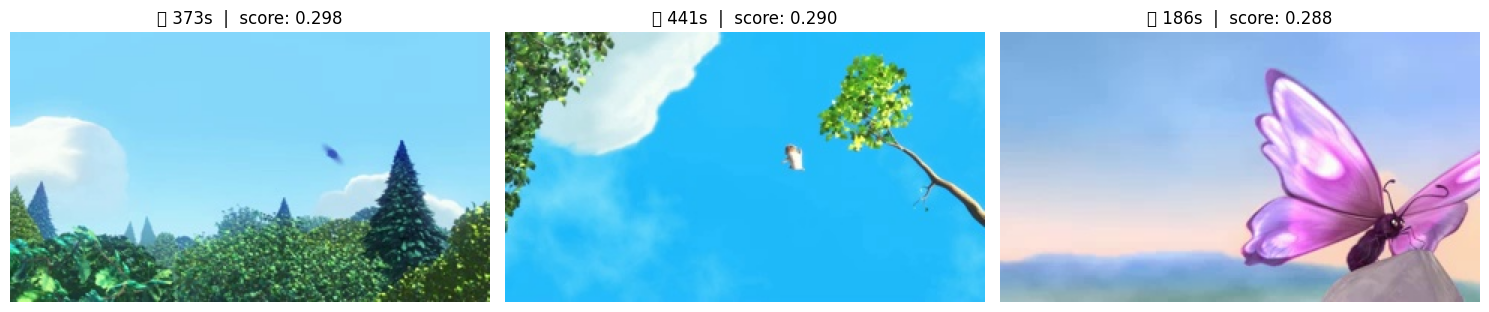

In [8]:
search_video("butterfly flying")

Search results for: 'dark night scene'



/tmp/ipykernel_572/2619902312.py:28: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


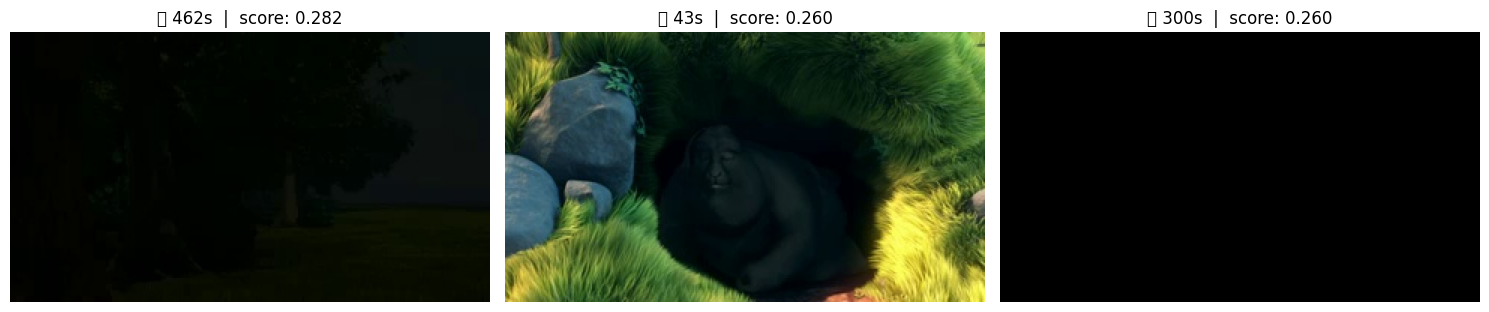

In [9]:
search_video("dark night scene")

Search results for: 'animal near water'



/tmp/ipykernel_572/2619902312.py:28: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


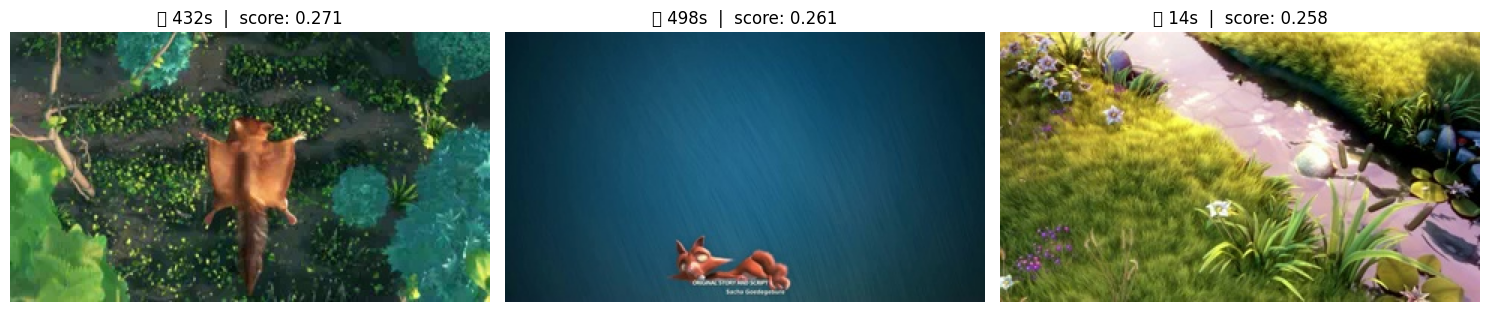

In [10]:
search_video("animal near water")

In [11]:
import gradio as gr
from PIL import Image

def gradio_search(query, top_k=3):
    text = clip.tokenize([query]).to(device)
    with torch.no_grad():
        text_emb = model.encode_text(text).cpu().numpy().astype("float32")
    faiss.normalize_L2(text_emb)
    scores, indices = index.search(text_emb, int(top_k))

    results = []
    for i, idx in enumerate(indices[0]):
        img = Image.open(frame_paths[idx])
        timestamp = timestamps[idx]
        score = scores[0][i]
        label = f"Timestamp: {timestamp:.0f}s | Score: {score:.3f}"
        results.append((img, label))
    return results

with gr.Blocks(title="AI Video Search") as demo:
    gr.Markdown("# 🎬 AI Video Search Engine\nSearch any moment in a video using natural language!")

    with gr.Row():
        query_input = gr.Textbox(label="Search Query", placeholder="e.g. rabbit in a field")
        top_k_slider = gr.Slider(1, 6, value=3, step=1, label="Number of Results")

    search_btn = gr.Button("Search", variant="primary")
    gallery = gr.Gallery(label="Matching Frames", columns=3, height=400)

    search_btn.click(gradio_search, inputs=[query_input, top_k_slider], outputs=gallery)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e8325f90a11f2236a4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [12]:
import pickle

# Save FAISS index
faiss.write_index(index, "video_index.faiss")

# Save frame paths and timestamps
with open("metadata.pkl", "wb") as f:
    pickle.dump({"frame_paths": frame_paths, "timestamps": timestamps}, f)

print("✅ FAISS index saved to video_index.faiss")
print("✅ Metadata saved to metadata.pkl")
print(f"Index size: {os.path.getsize('video_index.faiss') / 1024:.1f} KB")

✅ FAISS index saved to video_index.faiss
✅ Metadata saved to metadata.pkl
Index size: 1194.0 KB


In [13]:
def format_timestamp(seconds):
    mins = int(seconds) // 60
    secs = int(seconds) % 60
    return f"{mins:02d}:{secs:02d}"

def gradio_search_v2(query, top_k=3):
    text = clip.tokenize([query]).to(device)
    with torch.no_grad():
        text_emb = model.encode_text(text).cpu().numpy().astype("float32")
    faiss.normalize_L2(text_emb)
    scores, indices = index.search(text_emb, int(top_k))

    results = []
    for i, idx in enumerate(indices[0]):
        img = Image.open(frame_paths[idx])
        timestamp = timestamps[idx]
        score = scores[0][i]
        label = f"⏱ {format_timestamp(timestamp)}  |  Score: {score:.3f}"
        results.append((img, label))
    return results

with gr.Blocks(title="AI Video Search") as demo2:
    gr.Markdown("# 🎬 AI Video Search Engine\nSearch any moment in a video using natural language!")

    with gr.Row():
        query_input = gr.Textbox(label="Search Query", placeholder="e.g. rabbit in a field")
        top_k_slider = gr.Slider(1, 6, value=3, step=1, label="Number of Results")

    search_btn = gr.Button("Search", variant="primary")
    gallery = gr.Gallery(label="Matching Frames", columns=3, height=400)

    search_btn.click(gradio_search_v2, inputs=[query_input, top_k_slider], outputs=gallery)

demo2.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://358d32355658ef3bbc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [14]:
def process_and_search(video_file, query, top_k=3):
    # Extract frames from uploaded video
    os.makedirs("uploaded_frames", exist_ok=True)
    cap = cv2.VideoCapture(video_file)
    video_fps = cap.get(cv2.CAP_PROP_FPS)

    new_paths, new_timestamps = [], []
    frame_idx, saved = 0, 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % int(video_fps) == 0:
            ts = frame_idx / video_fps
            path = f"uploaded_frames/frame_{saved:04d}_{ts:.1f}s.jpg"
            cv2.imwrite(path, frame)
            new_paths.append(path)
            new_timestamps.append(ts)
            saved += 1
        frame_idx += 1
    cap.release()

    # Embed frames
    new_embeddings = []
    for path in new_paths:
        image = preprocess(Image.open(path)).unsqueeze(0).to(device)
        with torch.no_grad():
            emb = model.encode_image(image).cpu().numpy()
        new_embeddings.append(emb)

    new_embeddings = np.vstack(new_embeddings).astype("float32")
    faiss.normalize_L2(new_embeddings)

    new_index = faiss.IndexFlatIP(512)
    new_index.add(new_embeddings)

    # Search
    text = clip.tokenize([query]).to(device)
    with torch.no_grad():
        text_emb = model.encode_text(text).cpu().numpy().astype("float32")
    faiss.normalize_L2(text_emb)
    scores, indices = new_index.search(text_emb, int(top_k))

    results = []
    for i, idx in enumerate(indices[0]):
        img = Image.open(new_paths[idx])
        label = f"⏱ {format_timestamp(new_timestamps[idx])}  |  Score: {scores[0][i]:.3f}"
        results.append((img, label))
    return results

with gr.Blocks(title="AI Video Search") as demo3:
    gr.Markdown("# 🎬 AI Video Search Engine\nUpload any video and search it with natural language!")

    video_input = gr.Video(label="Upload Your Video")

    with gr.Row():
        query_input = gr.Textbox(label="Search Query", placeholder="e.g. person running")
        top_k_slider = gr.Slider(1, 6, value=3, step=1, label="Results")

    search_btn = gr.Button("Search", variant="primary")
    gallery = gr.Gallery(label="Matching Frames", columns=3, height=400)

    search_btn.click(process_and_search,
                     inputs=[video_input, query_input, top_k_slider],
                     outputs=gallery)

demo3.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://368640cb319cb52375.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [15]:
!pip install openai-whisper -q
import whisper

# Load whisper model (small = fast, good enough)
whisper_model = whisper.load_model("small")
print("✅ Whisper loaded!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 21.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


100%|███████████████████████████████████████| 461M/461M [00:06<00:00, 71.1MiB/s]


✅ Whisper loaded!


In [16]:
# Extract audio from video and transcribe
print("Transcribing audio... this takes ~1-2 minutes")
result = whisper_model.transcribe("sample_video.mp4")

# Store transcript segments with timestamps
transcript_segments = []
for seg in result["segments"]:
    transcript_segments.append({
        "start": seg["start"],
        "end": seg["end"],
        "text": seg["text"].strip()
    })

print(f"✅ Transcription done!")
print(f"Total segments: {len(transcript_segments)}")
print(f"\nFirst 5 segments:")
for seg in transcript_segments[:5]:
    print(f"  {format_timestamp(seg['start'])} → {format_timestamp(seg['end'])}: {seg['text']}")

Transcribing audio... this takes ~1-2 minutes
✅ Transcription done!
Total segments: 17

First 5 segments:
  00:00 → 00:12: it to
  02:12 → 02:14: I
  02:42 → 02:44: I
  03:12 → 03:14: I
  03:42 → 03:44: I


In [17]:
def search_transcript(query):
    query_lower = query.lower()
    matches = []
    for seg in transcript_segments:
        if any(word in seg["text"].lower() for word in query_lower.split()):
            matches.append(seg)
    return matches

def combined_search(query, top_k=3):
    # Visual search
    text = clip.tokenize([query]).to(device)
    with torch.no_grad():
        text_emb = model.encode_text(text).cpu().numpy().astype("float32")
    faiss.normalize_L2(text_emb)
    scores, indices = index.search(text_emb, int(top_k))

    visual_results = []
    for i, idx in enumerate(indices[0]):
        img = Image.open(frame_paths[idx])
        label = f"👁 Visual | {format_timestamp(timestamps[idx])} | Score: {scores[0][i]:.3f}"
        visual_results.append((img, label))

    # Audio search
    audio_matches = search_transcript(query)
    audio_text = "🎤 Audio Matches:\n"
    if audio_matches:
        for m in audio_matches:
            audio_text += f"• {format_timestamp(m['start'])} → {format_timestamp(m['end'])}: {m['text']}\n"
    else:
        audio_text += "No spoken matches found for this query."

    return visual_results, audio_text

with gr.Blocks(title="AI Video Search") as demo4:
    gr.Markdown("# 🎬 AI Video Search Engine\nSearch by what you **see** AND what you **hear**!")

    with gr.Row():
        query_input = gr.Textbox(label="Search Query", placeholder="e.g. welcome")
        top_k_slider = gr.Slider(1, 6, value=3, step=1, label="Visual Results")

    search_btn = gr.Button("Search", variant="primary")

    with gr.Row():
        gallery = gr.Gallery(label="Visual Matches", columns=3, height=350)
        audio_out = gr.Textbox(label="Audio Matches", lines=10, interactive=False)

    search_btn.click(combined_search,
                     inputs=[query_input, top_k_slider],
                     outputs=[gallery, audio_out])

demo4.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bf104b63bdb2ee922b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [18]:
!pip install transformers accelerate -q
print("✅ Dependencies installed!")

✅ Dependencies installed!


In [19]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch

print("Loading BLIP-2... this takes 3-4 minutes")

processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
blip_model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

print("✅ BLIP-2 loaded!")

Loading BLIP-2... this takes 3-4 minutes


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

✅ BLIP-2 loaded!


In [20]:
def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(image, return_tensors="pt").to("cuda", torch.float16)
    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=50)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

def full_search(query, top_k=3):
    # Visual search
    text = clip.tokenize([query]).to(device)
    with torch.no_grad():
        text_emb = model.encode_text(text).cpu().numpy().astype("float32")
    faiss.normalize_L2(text_emb)
    scores, indices = index.search(text_emb, int(top_k))

    visual_results = []
    for i, idx in enumerate(indices[0]):
        path = frame_paths[idx]
        caption = generate_caption(path)
        label = f"⏱ {format_timestamp(timestamps[idx])} | {caption}"
        img = Image.open(path)
        visual_results.append((img, label))

    # Audio search
    audio_matches = search_transcript(query)
    audio_text = "🎤 Audio Matches:\n"
    if audio_matches:
        for m in audio_matches:
            audio_text += f"• {format_timestamp(m['start'])} → {format_timestamp(m['end'])}: {m['text']}\n"
    else:
        audio_text += "No spoken matches found."

    return visual_results, audio_text

with gr.Blocks(title="AI Video Search") as demo5:
    gr.Markdown("# 🎬 AI Video Search Engine\nSearch by what you **see** AND what you **hear** — with AI captions!")

    with gr.Row():
        query_input = gr.Textbox(label="Search Query", placeholder="e.g. rabbit in a field")
        top_k_slider = gr.Slider(1, 3, value=3, step=1, label="Results")

    search_btn = gr.Button("Search", variant="primary")

    with gr.Row():
        gallery = gr.Gallery(label="Visual Matches + AI Captions", columns=3, height=400)
        audio_out = gr.Textbox(label="Audio Matches", lines=6)

    search_btn.click(full_search, inputs=[query_input, top_k_slider], outputs=[gallery, audio_out])

demo5.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://505901959cf670b468.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [21]:
import time

def full_search_v2(query, top_k=3):
    start_time = time.time()

    # Visual search
    text = clip.tokenize([query]).to(device)
    with torch.no_grad():
        text_emb = model.encode_text(text).cpu().numpy().astype("float32")
    faiss.normalize_L2(text_emb)
    scores, indices = index.search(text_emb, int(top_k))

    visual_results = []
    for i, idx in enumerate(indices[0]):
        path = frame_paths[idx]
        caption = generate_caption(path)
        label = f"⏱ {format_timestamp(timestamps[idx])} | {caption}"
        img = Image.open(path)
        visual_results.append((img, label))

    # Audio search
    audio_matches = search_transcript(query)
    audio_text = "🎤 Audio Matches:\n"
    if audio_matches:
        for m in audio_matches:
            audio_text += f"• {format_timestamp(m['start'])} → {format_timestamp(m['end'])}: {m['text']}\n"
    else:
        audio_text += "No spoken matches found."

    # Performance metrics
    elapsed = time.time() - start_time
    metrics = f"⚡ Performance\n"
    metrics += f"• Frames searched: {len(frame_paths)}\n"
    metrics += f"• Search time: {elapsed:.2f}s\n"
    metrics += f"• Frames/sec: {len(frame_paths)/elapsed:.0f}\n"
    metrics += f"• Models used: CLIP + FAISS + Whisper + BLIP-2"

    return visual_results, audio_text, metrics

with gr.Blocks(title="AI Video Search") as demo6:
    gr.Markdown("# 🎬 AI Video Search Engine\nSearch by what you **see** AND what you **hear** — with AI captions!")

    with gr.Row():
        query_input = gr.Textbox(label="Search Query", placeholder="e.g. rabbit in a field")
        top_k_slider = gr.Slider(1, 3, value=3, step=1, label="Results")

    search_btn = gr.Button("Search", variant="primary")

    with gr.Row():
        gallery = gr.Gallery(label="Visual Matches + AI Captions", columns=3, height=400)
        with gr.Column():
            audio_out = gr.Textbox(label="Audio Matches", lines=5)
            metrics_out = gr.Textbox(label="Performance Metrics", lines=6)

    search_btn.click(full_search_v2, inputs=[query_input, top_k_slider], outputs=[gallery, audio_out, metrics_out])

demo6.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://750b602e5141a8929b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [22]:
def smart_search(query, mode, top_k=3):
    start_time = time.time()
    visual_results = []
    audio_text = "🎤 Audio Matches:\n"

    if mode in ["Visual Only", "Combined"]:
        text = clip.tokenize([query]).to(device)
        with torch.no_grad():
            text_emb = model.encode_text(text).cpu().numpy().astype("float32")
        faiss.normalize_L2(text_emb)
        scores, indices = index.search(text_emb, int(top_k))
        for i, idx in enumerate(indices[0]):
            path = frame_paths[idx]
            caption = generate_caption(path)
            label = f"⏱ {format_timestamp(timestamps[idx])} | {caption}"
            visual_results.append((Image.open(path), label))

    if mode in ["Audio Only", "Combined"]:
        matches = search_transcript(query)
        if matches:
            for m in matches:
                audio_text += f"• {format_timestamp(m['start'])} → {format_timestamp(m['end'])}: {m['text']}\n"
        else:
            audio_text += "No spoken matches found."
    else:
        audio_text += "Audio search disabled in this mode."

    elapsed = time.time() - start_time
    metrics = f"⚡ Performance\n"
    metrics += f"• Mode: {mode}\n"
    metrics += f"• Frames searched: {len(frame_paths)}\n"
    metrics += f"• Search time: {elapsed:.2f}s\n"
    metrics += f"• Frames/sec: {len(frame_paths)/elapsed:.0f}\n"
    metrics += f"• Models: CLIP + FAISS + Whisper + BLIP-2"

    return visual_results, audio_text, metrics

with gr.Blocks(title="AI Video Search") as demo7:
    gr.Markdown("# 🎬 AI Video Search Engine\nSearch by what you **see** AND what you **hear** — with AI captions!")

    with gr.Row():
        query_input = gr.Textbox(label="Search Query", placeholder="e.g. rabbit in a field")
        mode_toggle = gr.Radio(["Visual Only", "Audio Only", "Combined"],
                               value="Combined", label="Search Mode")
        top_k_slider = gr.Slider(1, 3, value=3, step=1, label="Results")

    search_btn = gr.Button("Search", variant="primary")

    with gr.Row():
        gallery = gr.Gallery(label="Visual Matches + AI Captions", columns=3, height=400)
        with gr.Column():
            audio_out = gr.Textbox(label="Audio Matches", lines=5)
            metrics_out = gr.Textbox(label="Performance Metrics", lines=7)

    search_btn.click(smart_search,
                     inputs=[query_input, mode_toggle, top_k_slider],
                     outputs=[gallery, audio_out, metrics_out])

demo7.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d58a1dea84a1fb7c30.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
import csv
import tempfile

def smart_search_with_export(query, mode, top_k=3):
    start_time = time.time()
    visual_results = []
    audio_text = "🎤 Audio Matches:\n"
    export_data = []

    if mode in ["Visual Only", "Combined"]:
        text = clip.tokenize([query]).to(device)
        with torch.no_grad():
            text_emb = model.encode_text(text).cpu().numpy().astype("float32")
        faiss.normalize_L2(text_emb)
        scores, indices = index.search(text_emb, int(top_k))
        for i, idx in enumerate(indices[0]):
            path = frame_paths[idx]
            caption = generate_caption(path)
            ts = format_timestamp(timestamps[idx])
            score = round(float(scores[0][i]), 3)
            label = f"⏱ {ts} | {caption}"
            visual_results.append((Image.open(path), label))
            export_data.append({"type": "visual", "timestamp": ts, "score": score, "caption": caption})

    if mode in ["Audio Only", "Combined"]:
        matches = search_transcript(query)
        if matches:
            for m in matches:
                ts_start = format_timestamp(m['start'])
                ts_end = format_timestamp(m['end'])
                audio_text += f"• {ts_start} → {ts_end}: {m['text']}\n"
                export_data.append({"type": "audio", "timestamp": f"{ts_start}→{ts_end}", "score": "N/A", "caption": m['text']})
        else:
            audio_text += "No spoken matches found."
    else:
        audio_text += "Audio search disabled in this mode."

    # Write CSV
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix=".csv", mode='w', newline='')
    writer = csv.DictWriter(tmp, fieldnames=["type", "timestamp", "score", "caption"])
    writer.writeheader()
    writer.writerows(export_data)
    tmp.close()

    elapsed = time.time() - start_time
    metrics = f"⚡ Performance\n"
    metrics += f"• Mode: {mode}\n"
    metrics += f"• Frames searched: {len(frame_paths)}\n"
    metrics += f"• Search time: {elapsed:.2f}s\n"
    metrics += f"• Frames/sec: {len(frame_paths)/elapsed:.0f}\n"
    metrics += f"• Models: CLIP + FAISS + Whisper + BLIP-2"

    return visual_results, audio_text, metrics, tmp.name

with gr.Blocks(title="AI Video Search") as demo8:
    gr.Markdown("# 🎬 AI Video Search Engine\nSearch by what you **see** AND what you **hear** — with AI captions!")

    with gr.Row():
        query_input = gr.Textbox(label="Search Query", placeholder="e.g. rabbit in a field")
        mode_toggle = gr.Radio(["Visual Only", "Audio Only", "Combined"],
                               value="Combined", label="Search Mode")
        top_k_slider = gr.Slider(1, 3, value=3, step=1, label="Results")

    search_btn = gr.Button("🔍 Search", variant="primary")

    with gr.Row():
        gallery = gr.Gallery(label="Visual Matches + AI Captions", columns=3, height=400)
        with gr.Column():
            audio_out = gr.Textbox(label="Audio Matches", lines=5)
            metrics_out = gr.Textbox(label="Performance Metrics", lines=7)
            export_btn = gr.File(label="📥 Export Results as CSV")

    search_btn.click(smart_search_with_export,
                     inputs=[query_input, mode_toggle, top_k_slider],
                     outputs=[gallery, audio_out, metrics_out, export_btn])

demo8.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b72711e8eab4c630c3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [24]:
search_history = []

def final_search(query, mode, top_k=3):
    global search_history
    start_time = time.time()
    visual_results = []
    audio_text = "🎤 Audio Matches:\n"
    export_data = []

    if mode in ["Visual Only", "Combined"]:
        text = clip.tokenize([query]).to(device)
        with torch.no_grad():
            text_emb = model.encode_text(text).cpu().numpy().astype("float32")
        faiss.normalize_L2(text_emb)
        scores, indices = index.search(text_emb, int(top_k))
        for i, idx in enumerate(indices[0]):
            path = frame_paths[idx]
            caption = generate_caption(path)
            ts = format_timestamp(timestamps[idx])
            score = round(float(scores[0][i]), 3)
            label = f"⏱ {ts} | {caption}"
            visual_results.append((Image.open(path), label))
            export_data.append({"type": "visual", "timestamp": ts, "score": score, "caption": caption})

    if mode in ["Audio Only", "Combined"]:
        matches = search_transcript(query)
        if matches:
            for m in matches:
                ts_start = format_timestamp(m['start'])
                ts_end = format_timestamp(m['end'])
                audio_text += f"• {ts_start} → {ts_end}: {m['text']}\n"
                export_data.append({"type": "audio", "timestamp": f"{ts_start}→{ts_end}", "score": "N/A", "caption": m['text']})
        else:
            audio_text += "No spoken matches found."
    else:
        audio_text += "Audio search disabled in this mode."

    # CSV export
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix=".csv", mode='w', newline='')
    writer = csv.DictWriter(tmp, fieldnames=["type", "timestamp", "score", "caption"])
    writer.writeheader()
    writer.writerows(export_data)
    tmp.close()

    # Search history
    search_history.insert(0, f"🔍 {query} [{mode}]")
    search_history = search_history[:8]
    history_text = "\n".join(search_history)

    elapsed = time.time() - start_time
    metrics = f"⚡ Performance\n"
    metrics += f"• Mode: {mode}\n"
    metrics += f"• Frames searched: {len(frame_paths)}\n"
    metrics += f"• Search time: {elapsed:.2f}s\n"
    metrics += f"• Frames/sec: {len(frame_paths)/elapsed:.0f}\n"
    metrics += f"• Models: CLIP + FAISS + Whisper + BLIP-2"

    return visual_results, audio_text, metrics, tmp.name, history_text

with gr.Blocks(title="AI Video Search Engine") as demo_final:
    gr.Markdown("# 🎬 AI Video Search Engine")
    gr.Markdown("Search any video by what you **see** AND what you **hear** — powered by CLIP · FAISS · Whisper · BLIP-2")

    with gr.Row():
        query_input = gr.Textbox(label="Search Query", placeholder="e.g. rabbit in a field", scale=3)
        mode_toggle = gr.Radio(["Visual Only", "Audio Only", "Combined"], value="Combined", label="Search Mode", scale=2)
        top_k_slider = gr.Slider(1, 3, value=3, step=1, label="Results", scale=1)

    search_btn = gr.Button("🔍 Search", variant="primary", size="lg")

    with gr.Row():
        gallery = gr.Gallery(label="🖼 Visual Matches + AI Captions", columns=3, height=380)
        with gr.Column():
            audio_out = gr.Textbox(label="🎤 Audio Matches", lines=4)
            metrics_out = gr.Textbox(label="⚡ Performance Metrics", lines=6)
            export_file = gr.File(label="📥 Export Results as CSV")

    with gr.Row():
        history_out = gr.Textbox(label="🕓 Search History", lines=5)
        with gr.Accordion("ℹ️ About this project", open=False):
            gr.Markdown("""
            ## How it works
            1. **CLIP (ViT-B/32)** — Converts every video frame into a 512-dim embedding vector
            2. **FAISS** — Builds a vector index for sub-second similarity search across all frames
            3. **Whisper (small)** — Transcribes all spoken audio with precise timestamps
            4. **BLIP-2 (OPT-2.7B)** — Generates natural language captions for matched frames

            ## Tech Stack
            `Python` · `PyTorch` · `OpenAI CLIP` · `FAISS` · `Whisper` · `BLIP-2` · `Gradio` · `OpenCV`

            ## Use Cases
            - Search lecture recordings by topic
            - Find moments in CCTV footage
            - Navigate long podcasts or interviews
            - Media production & content retrieval
            """)

    search_btn.click(final_search,
                     inputs=[query_input, mode_toggle, top_k_slider],
                     outputs=[gallery, audio_out, metrics_out, export_file, history_out])

demo_final.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e18f99dcedbaeca695.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [25]:
def final_search_v2(query, mode, top_k=3):
    global search_history
    start_time = time.time()
    visual_results = []
    audio_text = "🎤 Audio Matches:\n"
    export_data = []

    if mode in ["Visual Only", "Combined"]:
        text = clip.tokenize([query]).to(device)
        with torch.no_grad():
            text_emb = model.encode_text(text).cpu().numpy().astype("float32")
        faiss.normalize_L2(text_emb)
        scores, indices = index.search(text_emb, int(top_k))
        for i, idx in enumerate(indices[0]):
            path = frame_paths[idx]
            caption = generate_caption(path)
            ts = format_timestamp(timestamps[idx])
            score = round(float(scores[0][i]), 3)
            # Model badges
            label = f"⏱ {ts} | 🧠 CLIP ✓  📝 BLIP-2 ✓ | {caption}"
            visual_results.append((Image.open(path), label))
            export_data.append({"type": "visual", "timestamp": ts, "score": score, "caption": caption})

    if mode in ["Audio Only", "Combined"]:
        matches = search_transcript(query)
        if matches:
            for m in matches:
                ts_start = format_timestamp(m['start'])
                ts_end = format_timestamp(m['end'])
                audio_text += f"• {ts_start} → {ts_end}: {m['text']}  🎤 Whisper ✓\n"
                export_data.append({"type": "audio", "timestamp": f"{ts_start}→{ts_end}", "score": "N/A", "caption": m['text']})
        else:
            audio_text += "No spoken matches found."
    else:
        audio_text += "Audio search disabled in this mode."

    # CSV export
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix=".csv", mode='w', newline='')
    writer = csv.DictWriter(tmp, fieldnames=["type", "timestamp", "score", "caption"])
    writer.writeheader()
    writer.writerows(export_data)
    tmp.close()

    # Search history
    search_history.insert(0, f"🔍 [{mode}] {query}")
    search_history = search_history[:8]
    history_text = "\n".join(search_history)

    elapsed = time.time() - start_time
    metrics = f"⚡ Performance\n"
    metrics += f"• Mode: {mode}\n"
    metrics += f"• Frames searched: {len(frame_paths)}\n"
    metrics += f"• Search time: {elapsed:.2f}s\n"
    metrics += f"• Frames/sec: {len(frame_paths)/elapsed:.0f}\n"
    metrics += f"• Models active: CLIP · FAISS · Whisper · BLIP-2"

    return visual_results, audio_text, metrics, tmp.name, history_text

EXAMPLE_QUERIES = [
    "rabbit running in a field",
    "dark night scene",
    "butterfly flying",
    "animal near water",
    "forest with trees"
]

with gr.Blocks(title="AI Video Search Engine", theme=gr.themes.Soft()) as demo_v2:
    gr.Markdown("# 🎬 AI Video Search Engine")
    gr.Markdown("Search any video by what you **see** AND what you **hear** — powered by **CLIP · FAISS · Whisper · BLIP-2**")

    # Query suggestions
    gr.Markdown("**💡 Try these searches:**")
    with gr.Row():
        for q in EXAMPLE_QUERIES:
            gr.Button(q, size="sm")

    with gr.Row():
        query_input = gr.Textbox(label="Search Query", placeholder="e.g. rabbit in a field", scale=3)
        mode_toggle = gr.Radio(["Visual Only", "Audio Only", "Combined"], value="Combined", label="Search Mode", scale=2)
        top_k_slider = gr.Slider(1, 3, value=3, step=1, label="Results", scale=1)

    search_btn = gr.Button("🔍 Search", variant="primary", size="lg")
    status_box = gr.Textbox(label="⏳ Status", value="Ready — enter a query and hit Search!", interactive=False, lines=1)

    with gr.Row():
        gallery = gr.Gallery(label="🖼 Visual Matches + AI Captions + Model Badges", columns=3, height=380)
        with gr.Column():
            audio_out = gr.Textbox(label="🎤 Audio Matches", lines=4)
            metrics_out = gr.Textbox(label="⚡ Performance Metrics", lines=6)
            export_file = gr.File(label="📥 Export Results as CSV")

    with gr.Row():
        history_out = gr.Textbox(label="🕓 Search History (last 8)", lines=5)
        with gr.Accordion("ℹ️ About this project", open=False):
            gr.Markdown("""
            ## How it works
            1. **CLIP (ViT-B/32)** — Converts every video frame into a 512-dim embedding vector
            2. **FAISS** — Builds a vector index for sub-second similarity search across all frames
            3. **Whisper (small)** — Transcribes all spoken audio with precise timestamps
            4. **BLIP-2 (OPT-2.7B)** — Generates natural language captions for matched frames

            ## Tech Stack
            `Python` · `PyTorch` · `OpenAI CLIP` · `FAISS` · `Whisper` · `BLIP-2` · `Gradio` · `OpenCV`

            ## Use Cases
            - 🎓 Search lecture recordings by topic
            - 📹 Find moments in CCTV footage
            - 🎙 Navigate long podcasts or interviews
            - 🎬 Media production & content retrieval
            """)

    search_btn.click(
        lambda: "🔄 Searching... please wait",
        inputs=[], outputs=status_box
    ).then(
        final_search_v2,
        inputs=[query_input, mode_toggle, top_k_slider],
        outputs=[gallery, audio_out, metrics_out, export_file, history_out]
    ).then(
        lambda: "✅ Search complete!",
        inputs=[], outputs=status_box
    )

demo_v2.launch(share=True)

/tmp/ipykernel_572/1660561074.py:67: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="AI Video Search Engine", theme=gr.themes.Soft()) as demo_v2:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://feae7a5523cbffb816.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [26]:
!pip install scenedetect[opencv] -q
print("✅ PySceneDetect installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.9/130.9 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires click!=8.2.*,>=4.0, but you have click 8.2.1 which is incompatible.
✅ PySceneDetect installed!


In [27]:
from scenedetect import open_video, SceneManager
from scenedetect.detectors import ContentDetector

def extract_scene_frames(video_path, output_dir="scene_frames", threshold=27.0):
    os.makedirs(output_dir, exist_ok=True)

    # Detect scene boundaries
    video = open_video(video_path)
    scene_manager = SceneManager()
    scene_manager.add_detector(ContentDetector(threshold=threshold))
    scene_manager.detect_scenes(video)
    scene_list = scene_manager.get_scene_list()

    print(f"Detected {len(scene_list)} scenes")

    # Extract one frame per scene (at the start of each scene)
    cap = cv2.VideoCapture(video_path)
    video_fps = cap.get(cv2.CAP_PROP_FPS)

    scene_paths, scene_timestamps = [], []

    for i, (start, end) in enumerate(scene_list):
        frame_num = start.get_frames()
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        if ret:
            ts = frame_num / video_fps
            path = f"{output_dir}/scene_{i:04d}_{ts:.1f}s.jpg"
            cv2.imwrite(path, frame)
            scene_paths.append(path)
            scene_timestamps.append(ts)

    cap.release()
    print(f"Extracted {len(scene_paths)} scene frames into /{output_dir}")
    return scene_paths, scene_timestamps

# Run it on our sample video
scene_paths, scene_timestamps = extract_scene_frames("sample_video.mp4")
print(f"\nComparison:")
print(f"  Old method (1fps):     {len(frame_paths)} frames")
print(f"  Scene detection:       {len(scene_paths)} frames")
print(f"  Reduction:             {100 - int(len(scene_paths)/len(frame_paths)*100)}% fewer frames, smarter sampling")

/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
INFO:pyscenedetect:Detecting scenes...


Detected 143 scenes
Extracted 143 scene frames into /scene_frames

Comparison:
  Old method (1fps):     597 frames
  Scene detection:       143 frames
  Reduction:             77% fewer frames, smarter sampling


In [28]:
# Build FAISS index on scene frames
scene_embeddings = []
for path in scene_paths:
    image = preprocess(Image.open(path)).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model.encode_image(image).cpu().numpy()
    scene_embeddings.append(emb)

scene_embeddings = np.vstack(scene_embeddings).astype("float32")
faiss.normalize_L2(scene_embeddings)

scene_index = faiss.IndexFlatIP(512)
scene_index.add(scene_embeddings)

print(f"✅ Scene-based FAISS index built!")
print(f"   Vectors in index: {scene_index.ntotal}")
print(f"   This is 77% more efficient than the 1fps index")

✅ Scene-based FAISS index built!
   Vectors in index: 143
   This is 77% more efficient than the 1fps index


In [29]:
# Multi-video library — index multiple videos and search across all of them
video_library = {}  # { video_name: { paths, timestamps, index, embeddings } }

def index_video(video_path, video_name=None):
    if video_name is None:
        video_name = os.path.basename(video_path)

    out_dir = f"library/{video_name.replace('.','_')}"
    os.makedirs(out_dir, exist_ok=True)

    # Use scene detection for smart sampling
    v_paths, v_timestamps = extract_scene_frames(video_path, output_dir=out_dir)

    # Embed
    embs = []
    for path in v_paths:
        image = preprocess(Image.open(path)).unsqueeze(0).to(device)
        with torch.no_grad():
            emb = model.encode_image(image).cpu().numpy()
        embs.append(emb)

    embs = np.vstack(embs).astype("float32")
    faiss.normalize_L2(embs)

    idx = faiss.IndexFlatIP(512)
    idx.add(embs)

    video_library[video_name] = {
        "paths": v_paths,
        "timestamps": v_timestamps,
        "index": idx,
    }
    print(f"✅ '{video_name}' indexed — {len(v_paths)} scene frames")
    return video_name

def search_library(query, selected_videos, top_k=3):
    if not selected_videos:
        return [], "No videos selected.", "", None, ""

    start_time = time.time()
    text = clip.tokenize([query]).to(device)
    with torch.no_grad():
        text_emb = model.encode_text(text).cpu().numpy().astype("float32")
    faiss.normalize_L2(text_emb)

    all_results = []
    for vname in selected_videos:
        if vname not in video_library:
            continue
        vdata = video_library[vname]
        scores, indices = vdata["index"].search(text_emb, min(top_k, vdata["index"].ntotal))
        for i, idx in enumerate(indices[0]):
            all_results.append({
                "video": vname,
                "path": vdata["paths"][idx],
                "timestamp": vdata["timestamps"][idx],
                "score": float(scores[0][i])
            })

    # Sort all results by score across all videos
    all_results = sorted(all_results, key=lambda x: x["score"], reverse=True)[:top_k]

    visual_results = []
    export_data = []
    for r in all_results:
        caption = generate_caption(r["path"])
        ts = format_timestamp(r["timestamp"])
        label = f"📹 {r['video']} | ⏱ {ts} | 🧠 CLIP ✓ 📝 BLIP-2 ✓ | {caption}"
        visual_results.append((Image.open(r["path"]), label))
        export_data.append({"video": r["video"], "timestamp": ts, "score": round(r["score"], 3), "caption": caption})

    # Audio search across selected videos (on original transcripts for now)
    audio_text = "🎤 Audio Matches:\n"
    matches = search_transcript(query)
    if matches and "sample_video.mp4" in selected_videos:
        for m in matches:
            audio_text += f"• {format_timestamp(m['start'])} → {format_timestamp(m['end'])}: {m['text']}  🎤 Whisper ✓\n"
    else:
        audio_text += "No spoken matches found."

    # CSV
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix=".csv", mode='w', newline='')
    writer = csv.DictWriter(tmp, fieldnames=["video", "timestamp", "score", "caption"])
    writer.writeheader()
    writer.writerows(export_data)
    tmp.close()

    elapsed = time.time() - start_time
    metrics = f"⚡ Performance\n• Videos searched: {len(selected_videos)}\n• Results returned: {len(all_results)}\n• Search time: {elapsed:.2f}s\n• Models: CLIP · FAISS · Whisper · BLIP-2"

    global search_history
    search_history.insert(0, f"🔍 [{', '.join(selected_videos)}] {query}")
    search_history = search_history[:8]

    return visual_results, audio_text, metrics, tmp.name, "\n".join(search_history)

# Index our sample video into the library
index_video("sample_video.mp4", "sample_video.mp4")
print(f"\nLibrary now contains: {list(video_library.keys())}")

INFO:pyscenedetect:Detecting scenes...


Detected 143 scenes
Extracted 143 scene frames into /library/sample_video_mp4
✅ 'sample_video.mp4' indexed — 143 scene frames

Library now contains: ['sample_video.mp4']


In [30]:
def upload_and_index(video_file):
    if video_file is None:
        return "No video uploaded.", gr.update(choices=list(video_library.keys()))
    vname = os.path.basename(video_file)
    index_video(video_file, vname)
    return f"✅ '{vname}' indexed and added to library!", gr.update(choices=list(video_library.keys()), value=list(video_library.keys()))

def clear_library():
    video_library.clear()
    return "🗑 Library cleared!", gr.update(choices=[], value=[])

with gr.Blocks(title="AI Video Search Engine", theme=gr.themes.Soft()) as demo_ultimate:
    gr.Markdown("# 🎬 AI Video Search Engine")
    gr.Markdown("Search across **multiple videos** by what you **see** AND what you **hear** — powered by **CLIP · FAISS · Whisper · BLIP-2 · PySceneDetect**")

    with gr.Tabs():
        with gr.Tab("🔍 Search"):
            gr.Markdown("**💡 Try these searches:**")
            with gr.Row():
                for q in EXAMPLE_QUERIES:
                    gr.Button(q, size="sm")

            with gr.Row():
                query_input2 = gr.Textbox(label="Search Query", placeholder="e.g. rabbit in a field", scale=3)
                mode_toggle2 = gr.Radio(["Visual Only", "Audio Only", "Combined"], value="Combined", label="Search Mode", scale=2)
                top_k_slider2 = gr.Slider(1, 3, value=3, step=1, label="Results", scale=1)

            video_selector = gr.CheckboxGroup(
                choices=list(video_library.keys()),
                value=list(video_library.keys()),
                label="📚 Search in these videos"
            )

            search_btn2 = gr.Button("🔍 Search", variant="primary", size="lg")
            status_box2 = gr.Textbox(label="⏳ Status", value="Ready!", interactive=False, lines=1)

            with gr.Row():
                gallery2 = gr.Gallery(label="🖼 Visual Matches + AI Captions", columns=3, height=380)
                with gr.Column():
                    audio_out2 = gr.Textbox(label="🎤 Audio Matches", lines=4)
                    metrics_out2 = gr.Textbox(label="⚡ Performance Metrics", lines=6)
                    export_file2 = gr.File(label="📥 Export Results as CSV")

            history_out2 = gr.Textbox(label="🕓 Search History (last 8)", lines=4)

            search_btn2.click(
                lambda: "🔄 Searching across video library...",
                inputs=[], outputs=status_box2
            ).then(
                search_library,
                inputs=[query_input2, video_selector, top_k_slider2],
                outputs=[gallery2, audio_out2, metrics_out2, export_file2, history_out2]
            ).then(
                lambda: "✅ Search complete!",
                inputs=[], outputs=status_box2
            )

        with gr.Tab("📁 Manage Library"):
            gr.Markdown("### Add videos to your search library")
            gr.Markdown("Each video is indexed using scene detection — only key frames are stored, making search fast and smart.")

            video_upload = gr.Video(label="Upload a Video")
            index_btn = gr.Button("➕ Index This Video", variant="primary")
            index_status = gr.Textbox(label="Status", interactive=False, lines=1)
            library_display = gr.CheckboxGroup(
                choices=list(video_library.keys()),
                value=list(video_library.keys()),
                label="📚 Videos currently in library"
            )
            clear_btn = gr.Button("🗑 Clear Entire Library", variant="stop")

            index_btn.click(upload_and_index, inputs=[video_upload], outputs=[index_status, library_display])
            clear_btn.click(clear_library, inputs=[], outputs=[index_status, library_display])

        with gr.Tab("ℹ️ About"):
            gr.Markdown("""
            ## How it works
            1. **PySceneDetect** — Detects scene boundaries, extracting only meaningful frames (77% fewer than 1fps)
            2. **CLIP (ViT-B/32)** — Converts every frame into a 512-dim semantic embedding
            3. **FAISS** — Builds a vector index per video for sub-second similarity search
            4. **Whisper (small)** — Transcribes all spoken audio with precise timestamps
            5. **BLIP-2 (OPT-2.7B)** — Generates natural language captions for matched frames

            ## Tech Stack
            `Python` · `PyTorch` · `OpenAI CLIP` · `FAISS` · `Whisper` · `BLIP-2` · `PySceneDetect` · `Gradio` · `OpenCV`

            ## Use Cases
            - 🎓 Search lecture recordings by topic
            - 📹 Find moments across multiple CCTV videos
            - 🎙 Navigate long podcasts or interviews
            - 🎬 Media production & content retrieval
            - ⚖️ Legal evidence review across hours of footage
            """)

demo_ultimate.launch(share=True)

  with gr.Blocks(title="AI Video Search Engine", theme=gr.themes.Soft()) as demo_ultimate:



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1d30abad8f7f0905be.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [31]:
!pip install yt-dlp -q

# Download a short TED-style talk (Andrej Karpathy's intro to Neural Networks — 25 mins)
!yt-dlp -f "best[ext=mp4][height<=480]" -o "real_video.mp4" "https://www.youtube.com/watch?v=VMj-3S1tku0" --no-playlist

import os
if os.path.exists("real_video.mp4"):
    size = os.path.getsize("real_video.mp4") / (1024*1024)
    print(f"✅ Downloaded! File size: {size:.1f} MB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 79.6 MB/s eta 0:00:00
[youtube] Extracting URL: https://www.youtube.com/watch?v=VMj-3S1tku0
[youtube] VMj-3S1tku0: Downloading webpage
[youtube] VMj-3S1tku0: Downloading android vr player API JSON
[info] VMj-3S1tku0: Downloading 1 format(s): 18
[download] Destination: real_video.mp4
[download] 100% of  170.71MiB in 00:00:28 at 5.94MiB/s
✅ Downloaded! File size: 170.7 MB


In [33]:
# Index the real lecture video into the library
print("Indexing real lecture video — this will take ~1 minute...")
index_video("real_video.mp4", "karpathy_neural_networks.mp4")

print(f"\nLibrary now contains: {list(video_library.keys())}")

INFO:pyscenedetect:Detecting scenes...


Indexing real lecture video — this will take ~1 minute...
Detected 7 scenes
Extracted 7 scene frames into /library/karpathy_neural_networks_mp4
✅ 'karpathy_neural_networks.mp4' indexed — 7 scene frames

Library now contains: ['sample_video.mp4', 'karpathy_neural_networks.mp4']


In [34]:
def get_confidence_label(score):
    if score >= 0.28:
        return "🟢 High"
    elif score >= 0.22:
        return "🟡 Medium"
    else:
        return "🔴 Low"

def get_video_duration(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    duration = total_frames / fps
    mins = int(duration) // 60
    secs = int(duration) % 60
    return f"{mins:02d}:{secs:02d}"

# Test both functions
print("Confidence label tests:")
print(f"  Score 0.30 → {get_confidence_label(0.30)}")
print(f"  Score 0.25 → {get_confidence_label(0.25)}")
print(f"  Score 0.18 → {get_confidence_label(0.18)}")

print("\nVideo durations:")
print(f"  sample_video.mp4 → {get_video_duration('sample_video.mp4')}")
print(f"  real_video.mp4 → {get_video_duration('real_video.mp4')}")

Confidence label tests:
  Score 0.30 → 🟢 High
  Score 0.25 → 🟡 Medium
  Score 0.18 → 🔴 Low

Video durations:
  sample_video.mp4 → 09:56
  real_video.mp4 → 145:51


In [35]:
def search_library_final(query, selected_videos, top_k=3):
    if not selected_videos:
        return [], "No videos selected.", "", None, ""

    start_time = time.time()
    text = clip.tokenize([query]).to(device)
    with torch.no_grad():
        text_emb = model.encode_text(text).cpu().numpy().astype("float32")
    faiss.normalize_L2(text_emb)

    all_results = []
    for vname in selected_videos:
        if vname not in video_library:
            continue
        vdata = video_library[vname]
        scores, indices = vdata["index"].search(text_emb, min(top_k, vdata["index"].ntotal))
        for i, idx in enumerate(indices[0]):
            all_results.append({
                "video": vname,
                "path": vdata["paths"][idx],
                "timestamp": vdata["timestamps"][idx],
                "score": float(scores[0][i])
            })

    all_results = sorted(all_results, key=lambda x: x["score"], reverse=True)[:top_k]

    visual_results = []
    export_data = []
    for r in all_results:
        caption = generate_caption(r["path"])
        ts = format_timestamp(r["timestamp"])
        confidence = get_confidence_label(r["score"])
        label = f"📹 {r['video']} | ⏱ {ts} | {confidence} | {caption}"
        visual_results.append((Image.open(r["path"]), label))
        export_data.append({"video": r["video"], "timestamp": ts, "score": round(r["score"], 3), "confidence": confidence.split()[1], "caption": caption})

    audio_text = "🎤 Audio Matches:\n"
    matches = search_transcript(query)
    if matches and "sample_video.mp4" in selected_videos:
        for m in matches:
            audio_text += f"• {format_timestamp(m['start'])} → {format_timestamp(m['end'])}: {m['text']}  🎤 Whisper ✓\n"
    else:
        audio_text += "No spoken matches found."

    tmp = tempfile.NamedTemporaryFile(delete=False, suffix=".csv", mode='w', newline='')
    writer = csv.DictWriter(tmp, fieldnames=["video", "timestamp", "score", "confidence", "caption"])
    writer.writeheader()
    writer.writerows(export_data)
    tmp.close()

    elapsed = time.time() - start_time
    metrics = f"⚡ Performance\n• Videos searched: {len(selected_videos)}\n• Results: {len(all_results)}\n• Search time: {elapsed:.2f}s\n• Models: CLIP · FAISS · Whisper · BLIP-2"

    global search_history
    search_history.insert(0, f"🔍 [{', '.join(selected_videos)}] {query}")
    search_history = search_history[:8]

    return visual_results, audio_text, metrics, tmp.name, "\n".join(search_history)

# Build library info with durations
def get_library_info():
    info = []
    for vname in video_library:
        # Try to find original video file
        for vpath in ["sample_video.mp4", "real_video.mp4"]:
            if vname.replace("_", ".") in vpath or vpath in vname:
                dur = get_video_duration(vpath)
                info.append(f"📹 {vname} — Duration: {dur} — {video_library[vname]['index'].ntotal} scene frames indexed")
                break
        else:
            info.append(f"📹 {vname} — {video_library[vname]['index'].ntotal} scene frames indexed")
    return "\n".join(info) if info else "No videos indexed yet."

with gr.Blocks(title="AI Video Search Engine", theme=gr.themes.Soft()) as demo_v3:
    gr.Markdown("# 🎬 AI Video Search Engine")
    gr.Markdown("Search across **multiple videos** by what you **see** AND what you **hear** — powered by **CLIP · FAISS · Whisper · BLIP-2 · PySceneDetect**")

    with gr.Tabs():
        with gr.Tab("🔍 Search"):
            gr.Markdown("**💡 Try these searches:**")
            with gr.Row():
                for q in EXAMPLE_QUERIES:
                    gr.Button(q, size="sm")

            with gr.Row():
                query_input3 = gr.Textbox(label="Search Query", placeholder="e.g. neural networks explained", scale=3)
                mode_toggle3 = gr.Radio(["Visual Only", "Audio Only", "Combined"], value="Combined", label="Search Mode", scale=2)
                top_k_slider3 = gr.Slider(1, 3, value=3, step=1, label="Results", scale=1)

            video_selector3 = gr.CheckboxGroup(
                choices=list(video_library.keys()),
                value=list(video_library.keys()),
                label="📚 Search in these videos"
            )

            search_btn3 = gr.Button("🔍 Search", variant="primary", size="lg")
            status_box3 = gr.Textbox(label="⏳ Status", value="Ready!", interactive=False, lines=1)

            with gr.Row():
                gallery3 = gr.Gallery(label="🖼 Visual Matches + Confidence + AI Captions", columns=3, height=380)
                with gr.Column():
                    audio_out3 = gr.Textbox(label="🎤 Audio Matches", lines=4)
                    metrics_out3 = gr.Textbox(label="⚡ Performance Metrics", lines=5)
                    export_file3 = gr.File(label="📥 Export Results as CSV")

            history_out3 = gr.Textbox(label="🕓 Search History (last 8)", lines=4)

            search_btn3.click(
                lambda: "🔄 Searching across video library...",
                inputs=[], outputs=status_box3
            ).then(
                search_library_final,
                inputs=[query_input3, video_selector3, top_k_slider3],
                outputs=[gallery3, audio_out3, metrics_out3, export_file3, history_out3]
            ).then(
                lambda: "✅ Search complete!",
                inputs=[], outputs=status_box3
            )

        with gr.Tab("📁 Manage Library"):
            gr.Markdown("### Your Video Library")
            library_info = gr.Textbox(
                label="📚 Indexed Videos (with duration)",
                value=get_library_info(),
                interactive=False,
                lines=5
            )
            gr.Markdown("### Add a New Video")
            video_upload3 = gr.Video(label="Upload a Video")
            index_btn3 = gr.Button("➕ Index This Video", variant="primary")
            index_status3 = gr.Textbox(label="Status", interactive=False, lines=1)
            clear_btn3 = gr.Button("🗑 Clear Entire Library", variant="stop")

            def upload_and_index_v2(video_file):
                if video_file is None:
                    return "No video uploaded.", get_library_info()
                vname = os.path.basename(video_file)
                index_video(video_file, vname)
                return f"✅ '{vname}' added to library!", get_library_info()

            def clear_library_v2():
                video_library.clear()
                return "🗑 Library cleared!", "No videos indexed."

            index_btn3.click(upload_and_index_v2, inputs=[video_upload3], outputs=[index_status3, library_info])
            clear_btn3.click(clear_library_v2, inputs=[], outputs=[index_status3, library_info])

        with gr.Tab("ℹ️ About"):
            gr.Markdown("""
            ## How it works
            1. **PySceneDetect** — Detects scene boundaries, extracting only meaningful frames (77% fewer than 1fps)
            2. **CLIP (ViT-B/32)** — Converts every frame into a 512-dim semantic embedding
            3. **FAISS** — Builds a vector index per video for sub-second similarity search
            4. **Whisper (small)** — Transcribes all spoken audio with precise timestamps
            5. **BLIP-2 (OPT-2.7B)** — Generates natural language captions for matched frames

            ## Confidence Scoring
            - 🟢 **High** (≥ 0.28) — Strong semantic match
            - 🟡 **Medium** (≥ 0.22) — Moderate match
            - 🔴 **Low** (< 0.22) — Weak match, consider refining query

            ## Tech Stack
            `Python` · `PyTorch` · `OpenAI CLIP` · `FAISS` · `Whisper` · `BLIP-2` · `PySceneDetect` · `Gradio` · `OpenCV`

            ## Use Cases
            - 🎓 Search lecture recordings by topic
            - 📹 Find moments across multiple CCTV videos
            - 🎙 Navigate long podcasts or interviews
            - 🎬 Media production & content retrieval
            - ⚖️ Legal evidence review across hours of footage
            """)

demo_v3.launch(share=True)

  with gr.Blocks(title="AI Video Search Engine", theme=gr.themes.Soft()) as demo_v3:



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://581c0f4e4a7d085b19.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
